In [7]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import Counter

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
import os

print("Current Location:")
print(os.getcwd())

print("\nAvailable Files:")
print(os.listdir())

Current Location:
c:\Users\pujak\OneDrive\Desktop\Indian-Job-Market-Analysis\Python

Available Files:
['Job_Market_Analysis.ipynb']


In [9]:
dataset_folder = "../Dataset"

print(os.listdir(dataset_folder))

['indian-job-market-dataset-2025.xlsx', 'Indian_Job_Market_Cleaned.csv', 'Top_20_Skills.csv']


In [10]:
# Load dataset

file_path = "../Dataset/indian-job-market-dataset-2025.xlsx"

df = pd.read_excel(file_path)

df.head()

df.shape

(97929, 17)

In [11]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              97929 non-null  str    
 1   jobId              97929 non-null  int64  
 2   currency           97929 non-null  str    
 3   jobUploaded        97929 non-null  str    
 4   companyName        97925 non-null  str    
 5   tagsAndSkills      97358 non-null  str    
 6   experience         95824 non-null  str    
 7   salary             97929 non-null  str    
 8   location           97929 non-null  str    
 9   companyId          97929 non-null  int64  
 10  ReviewsCount       62677 non-null  float64
 11  AggregateRating    62677 non-null  float64
 12  jobDescription     97929 non-null  str    
 13  minimumSalary      97358 non-null  float64
 14  maximumSalary      97358 non-null  float64
 15  minimumExperience  97358 non-null  float64
 16  maximumExperience  97358 non-null

In [12]:
# Missing value analysis

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

missing_report.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
AggregateRating,35252,36.00
ReviewsCount,35252,36.00
experience,2105,2.15
minimumSalary,571,0.58
tagsAndSkills,571,0.58
maximumExperience,571,0.58
maximumSalary,571,0.58
minimumExperience,571,0.58
companyName,4,0.00
title,0,0.00


In [13]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 247


In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

# Check new dataset size

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (97682, 17)


In [15]:
# Handling missing values

# Fill missing skills
df['tagsAndSkills'] = df['tagsAndSkills'].fillna('Not Available')

# Fill missing company names
df['companyName'] = df['companyName'].fillna('Not Available')

# Fill missing experience
df['experience'] = df['experience'].fillna('Not Available')

# Fill missing ratings and reviews
df['AggregateRating'] = df['AggregateRating'].fillna(0)
df['ReviewsCount'] = df['ReviewsCount'].fillna(0)

# Fill salary and experience numeric columns with median values
numeric_columns = [
    'minimumSalary',
    'maximumSalary',
    'minimumExperience',
    'maximumExperience'
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


# Check missing values again

df.isnull().sum()

title                0
jobId                0
currency             0
jobUploaded          0
companyName          0
tagsAndSkills        0
experience           0
salary               0
location             0
companyId            0
ReviewsCount         0
AggregateRating      0
jobDescription       0
minimumSalary        0
maximumSalary        0
minimumExperience    0
maximumExperience    0
dtype: int64

In [16]:
# Convert jobUploaded into datetime format

df['jobUploaded'] = pd.to_datetime(df['jobUploaded'], errors='coerce')

# Check data types

df.dtypes

C:\Users\pujak\AppData\Local\Temp\ipykernel_6248\1152156689.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['jobUploaded'] = pd.to_datetime(df['jobUploaded'], errors='coerce')


title                          str
jobId                        int64
currency                       str
jobUploaded          datetime64[s]
companyName                    str
tagsAndSkills                  str
experience                     str
salary                         str
location                       str
companyId                    int64
ReviewsCount               float64
AggregateRating            float64
jobDescription                 str
minimumSalary              float64
maximumSalary              float64
minimumExperience          float64
maximumExperience          float64
dtype: object

In [17]:
# Save cleaned dataset

clean_file_path = "../Dataset/Indian_Job_Market_Cleaned.csv"

df.to_csv(clean_file_path, index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [18]:
# Basic dataset overview

print("Total Job Records:", df.shape[0])

print("Total Columns:", df.shape[1])

print("Unique Companies:", df['companyName'].nunique())

print("Unique Job Titles:", df['title'].nunique())

print("Unique Locations:", df['location'].nunique())

Total Job Records: 97682
Total Columns: 17
Unique Companies: 18668
Unique Job Titles: 55104
Unique Locations: 10066


In [19]:
# Statistical summary of numerical columns

df.describe()

,jobId,jobUploaded,companyId,ReviewsCount,AggregateRating,minimumSalary,maximumSalary,minimumExperience,maximumExperience
count,9.768200e+04,0,9.768200e+04,97682.000000,97682.000000,9.768200e+04,9.768200e+04,97682.000000,97682.00000
mean,2.069450e+11,NaT,2.784013e+07,9394.119275,2.354590,1.971666e+05,3.167813e+05,3.952704,7.72863
min,1.012500e+10,NaT,3.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.00000
25%,1.808250e+11,NaT,2.320290e+05,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,5.00000
50%,2.508250e+11,NaT,2.891890e+06,49.000000,3.400000,0.000000e+00,0.000000e+00,3.000000,7.00000
75%,2.808250e+11,NaT,6.398332e+06,2604.000000,3.700000,2.000000e+05,3.750000e+05,5.000000,10.00000
max,3.112240e+11,NaT,1.251422e+08,104449.000000,5.000000,7.000000e+07,9.500000e+07,30.000000,35.00000
std,9.991504e+10,NaN,4.978862e+07,21020.575827,1.807877,5.628581e+05,8.400146e+05,3.571799,4.48734


In [20]:
# Check original jobUploaded values

df['jobUploaded'].head(10)

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
5   NaT
6   NaT
7   NaT
8   NaT
9   NaT
Name: jobUploaded, dtype: datetime64[s]

In [21]:
# Reload original dataset to restore jobUploaded values

df = pd.read_excel("../Dataset/indian-job-market-dataset-2025.xlsx")

# Check original date values

df['jobUploaded'].head()

0    6 Days Ago
1    6 Days Ago
2    6 Days Ago
3    6 Days Ago
4    6 Days Ago
Name: jobUploaded, dtype: str

In [22]:
import re

def convert_to_days(value):
    if pd.isna(value):
        return None
    
    value = str(value)
    
    # Extract number from text
    numbers = re.findall(r'\d+', value)
    
    if numbers:
        return int(numbers[0])
    
    return None


df['jobPostedDaysAgo'] = df['jobUploaded'].apply(convert_to_days)

# Check result

df[['jobUploaded', 'jobPostedDaysAgo']].head()

,jobUploaded,jobPostedDaysAgo
0,6 Days Ago,6.0
1,6 Days Ago,6.0
2,6 Days Ago,6.0
3,6 Days Ago,6.0
4,6 Days Ago,6.0


In [23]:
# Summary of job posting days

df['jobPostedDaysAgo'].describe()

count    86941.000000
mean         6.108648
std          2.867493
min          1.000000
25%          3.000000
50%          7.000000
75%          9.000000
max         25.000000
Name: jobPostedDaysAgo, dtype: float64

In [24]:
# Top 10 most demanded job titles

top_jobs = df['title'].value_counts().head(10)

top_jobs

title
Application Developer             2039
Application Lead                  1347
Sales Executive                    576
Software Development Engineer      497
Business Development Executive     457
Trust & Safety New Associate       348
Data Engineer                      339
Business Development Manager       323
Sales Manager                      319
Java Full Stack Developer          283
Name: count, dtype: int64

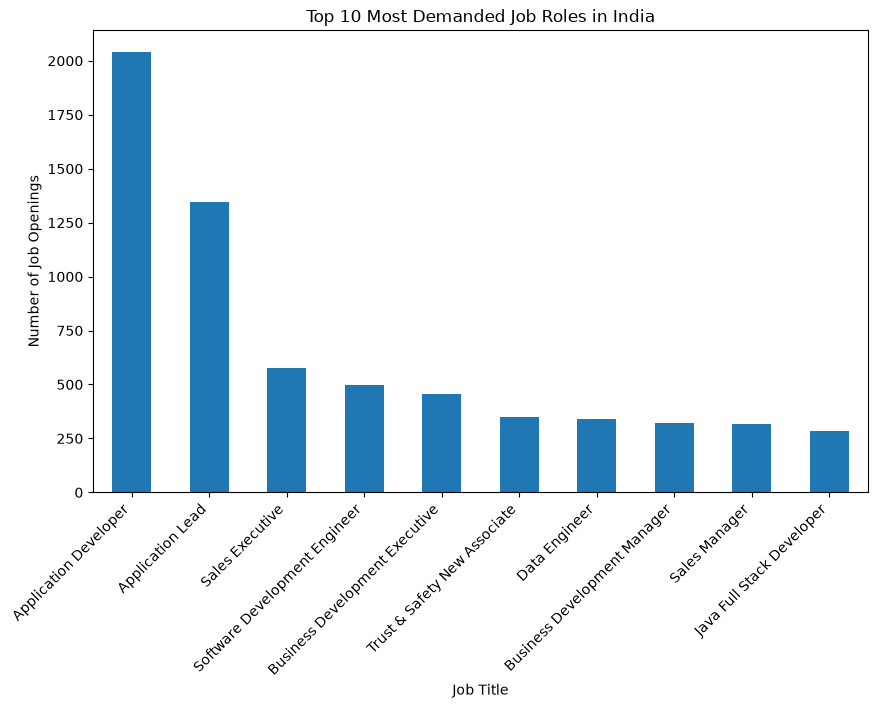

In [25]:
import matplotlib.pyplot as plt

# Top 10 job titles visualization

plt.figure(figsize=(10,6))

top_jobs.plot(kind='bar')

plt.title("Top 10 Most Demanded Job Roles in India")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Openings")

plt.xticks(rotation=45, ha='right')

plt.show()

In [26]:
# Top 10 Hiring Locations

top_locations = df['location'].value_counts().head(10)

print(top_locations)

location
Bengaluru      16823
Hyderabad       7669
Pune            6112
Chennai         4431
Gurugram        4233
Mumbai          4157
Noida           2695
Remote          1961
Ahmedabad       1726
Navi Mumbai     1453
Name: count, dtype: int64


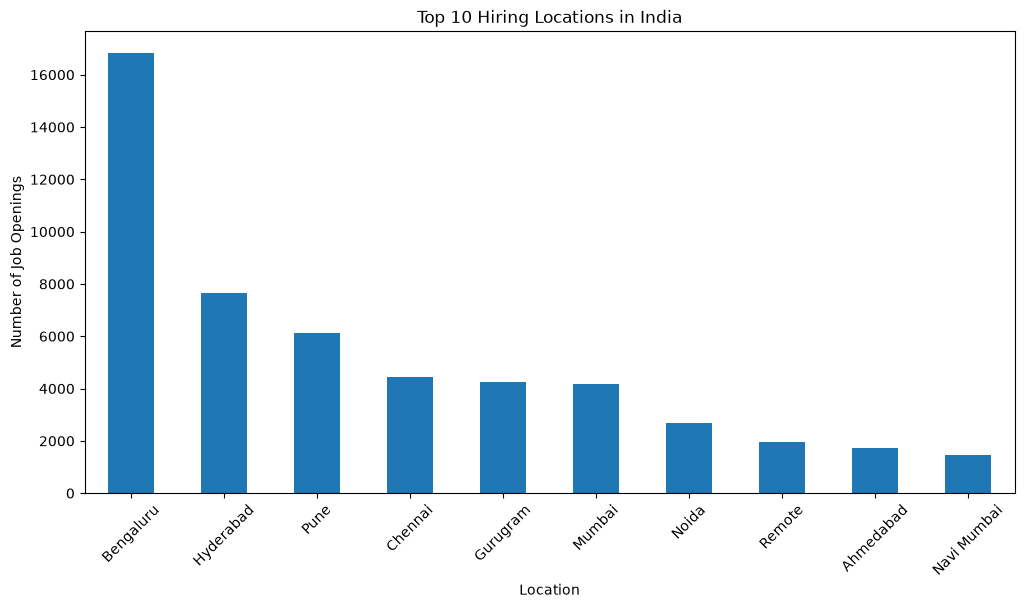

In [27]:
plt.figure(figsize=(12,6))

top_locations.plot(kind='bar')

plt.title("Top 10 Hiring Locations in India")
plt.xlabel("Location")
plt.ylabel("Number of Job Openings")

plt.xticks(rotation=45)

plt.show()

In [28]:
# Top 10 companies with the most job openings

top_companies = df['companyName'].value_counts().head(10)

print(top_companies)

companyName
Accenture                                8204
IDESLABS PRIVATE LIMITED                 2303
Wipro                                    1496
Krazy Mantra HR Solutions Pvt. Ltd       1028
Kotak Mahindra Bank                       987
PRO Hr Complete Solutions                 982
Infosys                                   938
Capgemini                                 700
IBM                                       687
PRADEEPIT CONSULTING SERVICES PVT LTD     618
Name: count, dtype: int64


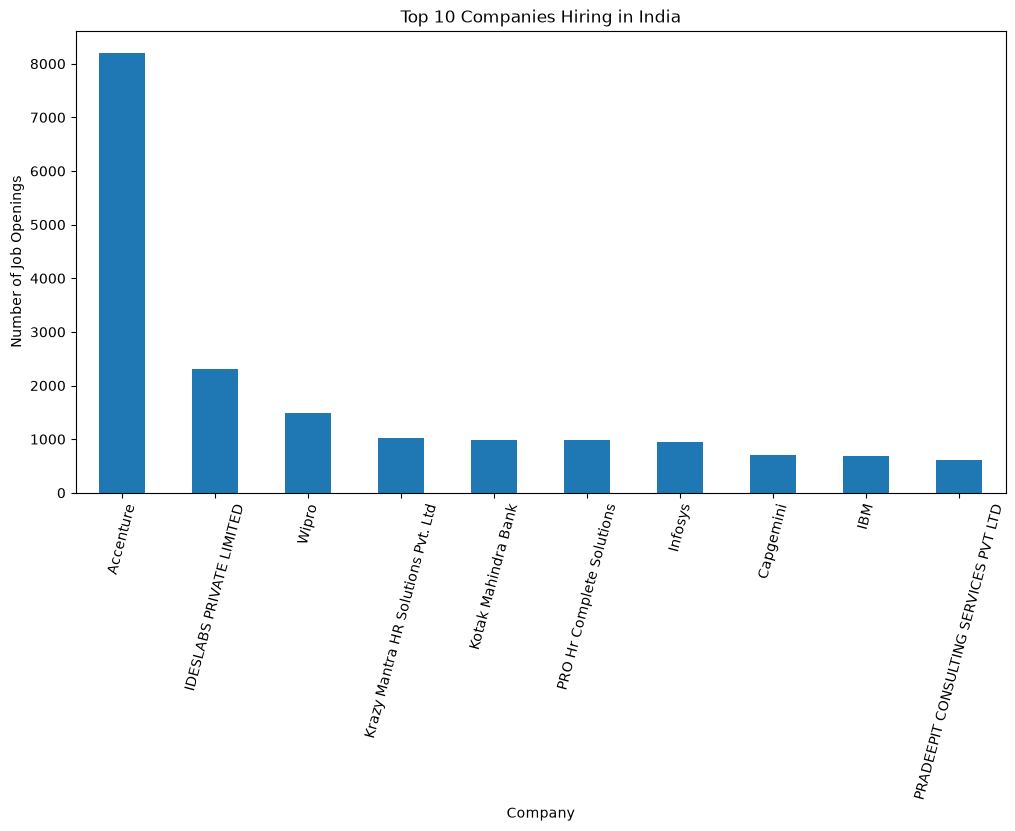

In [29]:
plt.figure(figsize=(12,6))

top_companies.plot(kind='bar')

plt.title("Top 10 Companies Hiring in India")
plt.xlabel("Company")
plt.ylabel("Number of Job Openings")

plt.xticks(rotation=75)

plt.show()

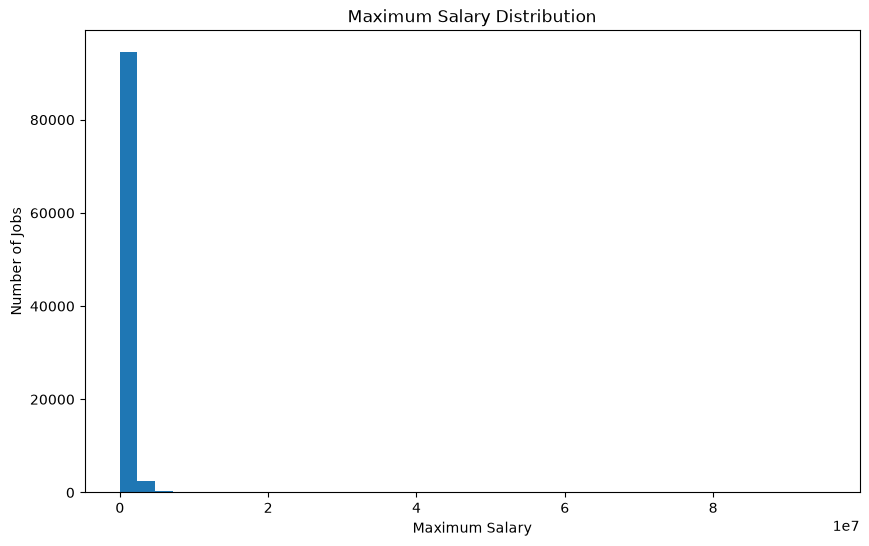

In [30]:
plt.figure(figsize=(10,6))

plt.hist(df['maximumSalary'], bins=40)

plt.title("Maximum Salary Distribution")
plt.xlabel("Maximum Salary")
plt.ylabel("Number of Jobs")

plt.show()

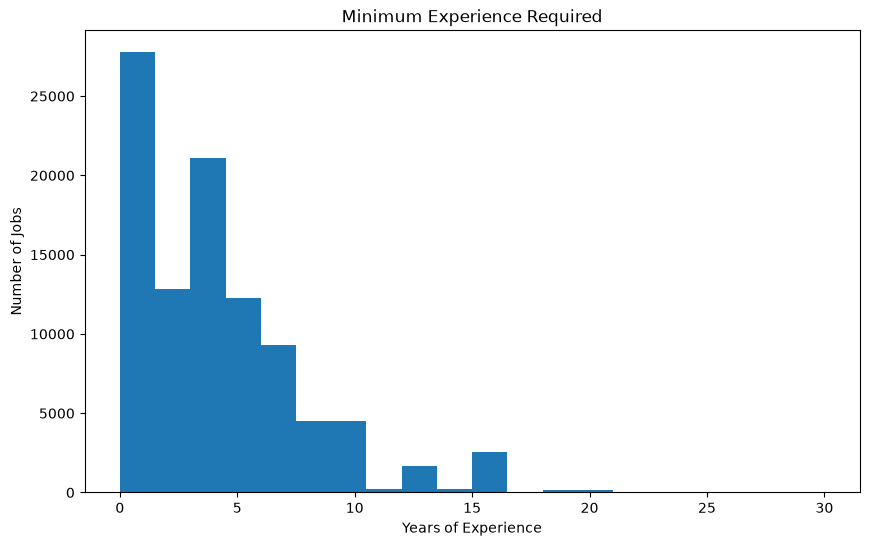

In [31]:
plt.figure(figsize=(10,6))

plt.hist(df['minimumExperience'], bins=20)

plt.title("Minimum Experience Required")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Jobs")

plt.show()

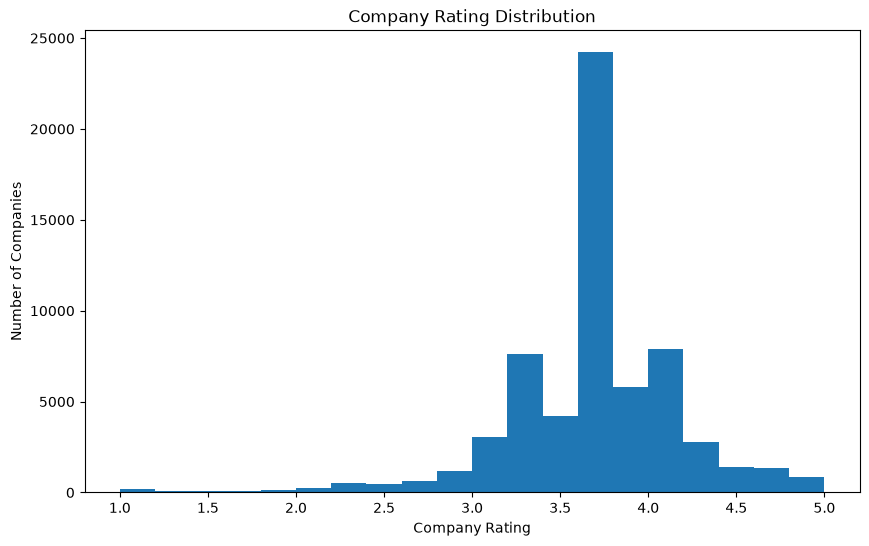

In [32]:
plt.figure(figsize=(10,6))

plt.hist(df['AggregateRating'], bins=20)

plt.title("Company Rating Distribution")
plt.xlabel("Company Rating")
plt.ylabel("Number of Companies")

plt.show()

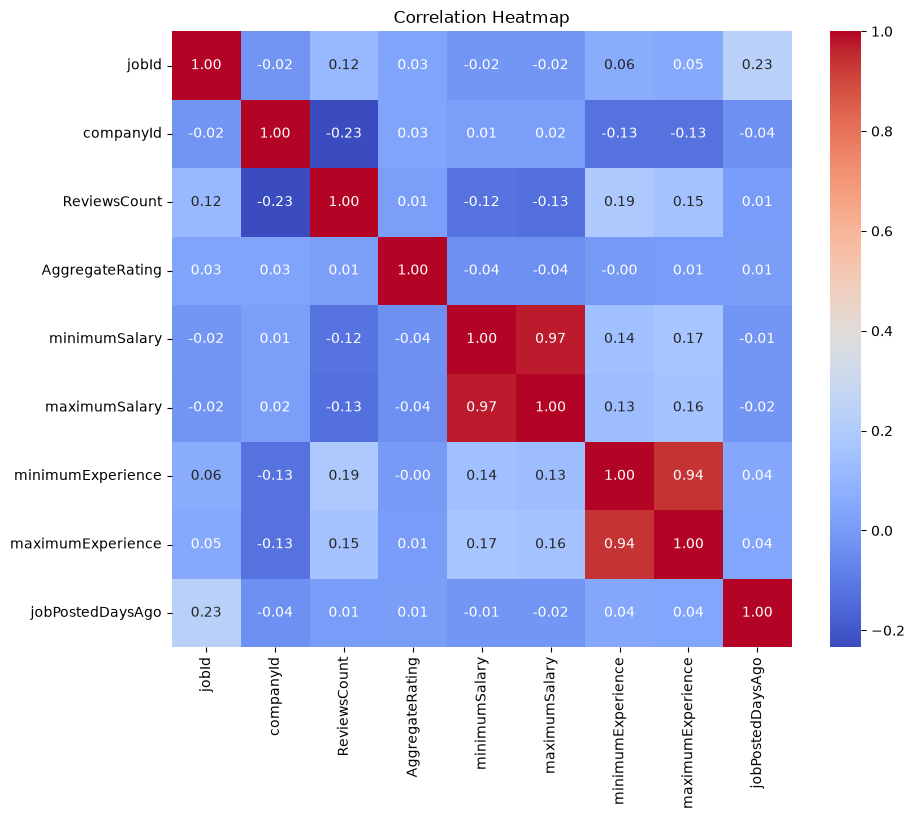

In [33]:
# Correlation Heatmap

import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
# Create Salary Category

df['SalaryCategory'] = pd.cut(
    df['maximumSalary'],
    bins=[-1, 500000, 1500000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

df[['maximumSalary', 'SalaryCategory']].head()

,maximumSalary,SalaryCategory
0,400000.0,Low
1,500000.0,Low
2,0.0,Low
3,200000.0,Low
4,1800000.0,High


In [35]:
# Create Experience Level

df['ExperienceLevel'] = pd.cut(
    df['minimumExperience'],
    bins=[-1, 1, 5, 100],
    labels=['Fresher', 'Mid-Level', 'Senior']
)

df[['minimumExperience', 'ExperienceLevel']].head(10)

,minimumExperience,ExperienceLevel
0,2.0,Mid-Level
1,6.0,Senior
2,12.0,Senior
3,0.0,Fresher
4,5.0,Mid-Level
5,10.0,Senior
6,3.0,Mid-Level
7,2.0,Mid-Level
8,2.0,Mid-Level
9,4.0,Mid-Level


In [36]:
# Count jobs by Experience Level

experience_counts = df['ExperienceLevel'].value_counts()

print(experience_counts)

ExperienceLevel
Mid-Level    46222
Fresher      27751
Senior       23385
Name: count, dtype: int64


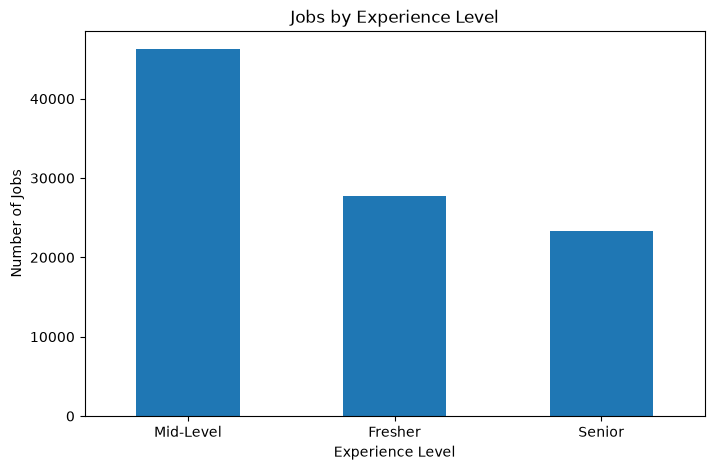

In [37]:
plt.figure(figsize=(8,5))

experience_counts.plot(kind='bar')

plt.title("Jobs by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=0)

plt.show()

In [38]:
# Average Maximum Salary by Experience Level

avg_salary_exp = (
    df.groupby('ExperienceLevel', observed=False)['maximumSalary']
      .mean()
      .sort_values()
)

print(avg_salary_exp)

ExperienceLevel
Mid-Level    257836.441521
Fresher      268836.106302
Senior       497797.938251
Name: maximumSalary, dtype: float64


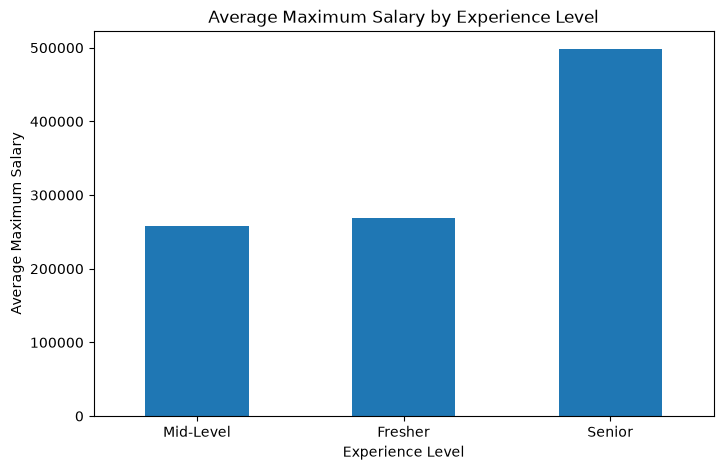

In [39]:
plt.figure(figsize=(8,5))

avg_salary_exp.plot(kind='bar')

plt.title("Average Maximum Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Maximum Salary")

plt.xticks(rotation=0)

plt.show()

In [40]:
# Average Maximum Salary by Location

location_salary = (
    df.groupby('location')['maximumSalary']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(location_salary)

location
Tamil Nadu, Kerala                                30000000.0
Kashipur, Dhanbad, Ajmer                          15000000.0
Hyderabad, Kakinada                               15000000.0
Sirsa, Kolhapur, Moradabad                        10000000.0
Jabalpur, Central African Republic, Aurangabad    10000000.0
Ambikapur, Raigarh, Raipur                        10000000.0
Khambhat, Anand, Vadodara                         10000000.0
Indore, Bhandara, Durgapur                        10000000.0
Indore, Chennai, Bengaluru                        10000000.0
Durgapur, Central African Republic, Firozabad      9500000.0
Name: maximumSalary, dtype: float64


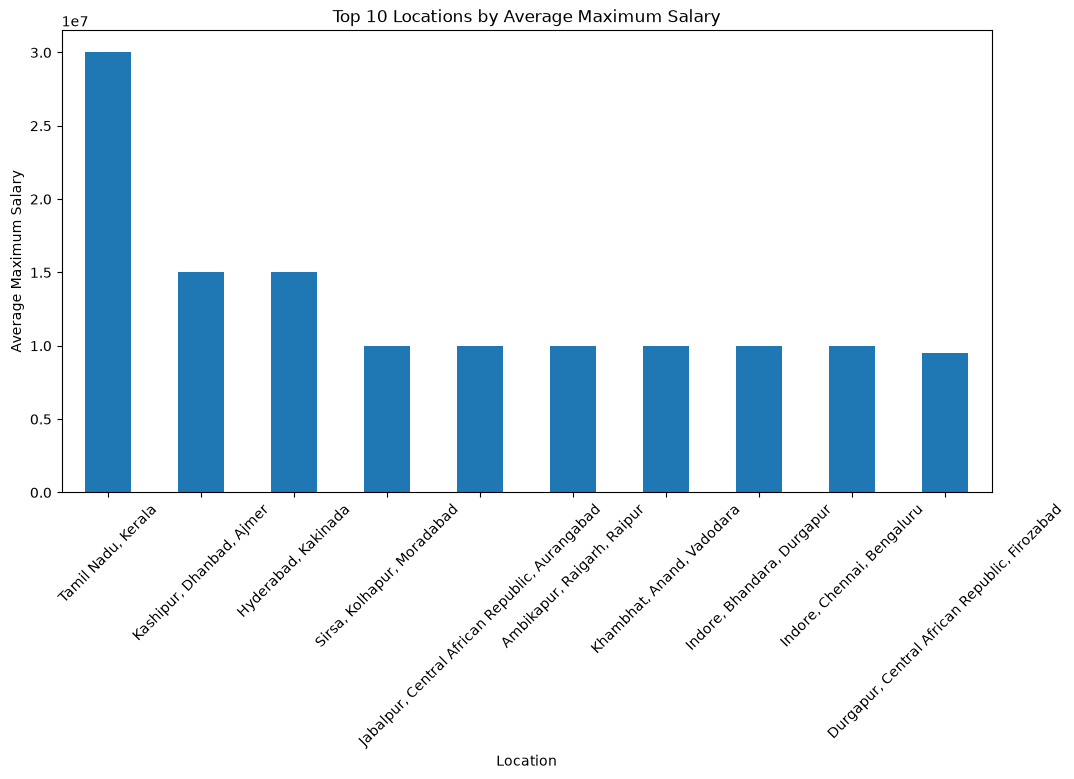

In [41]:
plt.figure(figsize=(12,6))

location_salary.plot(kind='bar')

plt.title("Top 10 Locations by Average Maximum Salary")
plt.xlabel("Location")
plt.ylabel("Average Maximum Salary")

plt.xticks(rotation=45)

plt.show()

In [42]:
# Top 10 companies by average maximum salary

company_salary = (
    df.groupby('companyName')['maximumSalary']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(company_salary)

companyName
European Company               30000000.0
Cambio Consulting              30000000.0
Holistic Solutions India       15000000.0
Sigma Placement Consultancy    12500000.0
Smartfoodsafe India            12000000.0
Inframart Realtech India       10800000.0
Filmy Gags Media               10125000.0
Multiple                       10000000.0
Netfreak Digital Media         10000000.0
Mavenhasten Consulting         10000000.0
Name: maximumSalary, dtype: float64


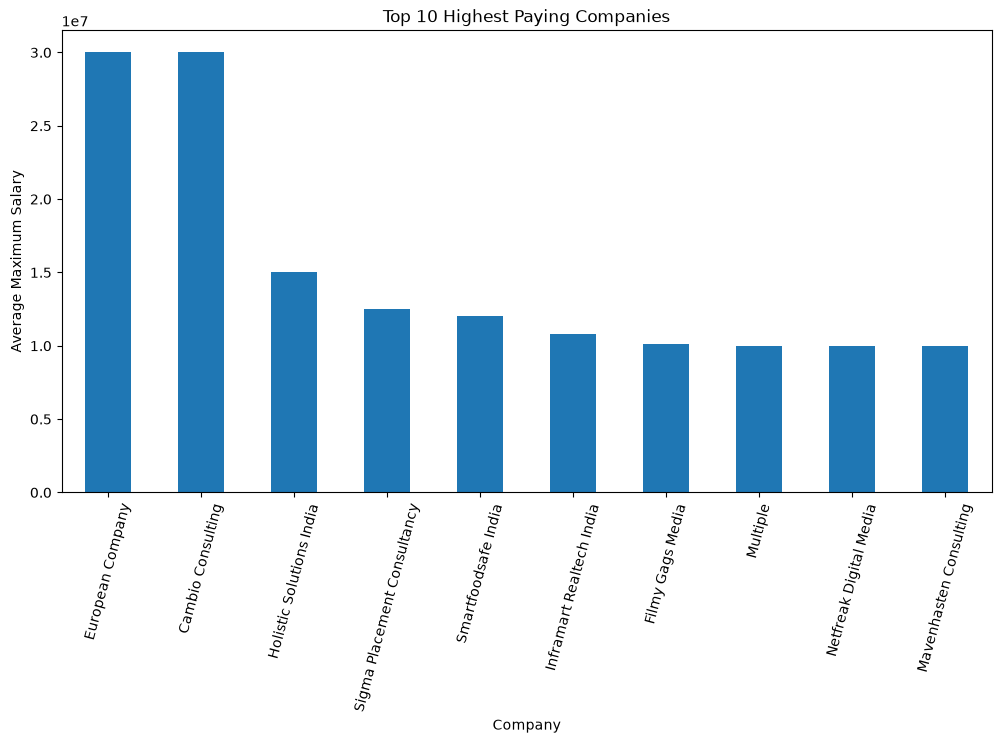

In [43]:
plt.figure(figsize=(12,6))

company_salary.plot(kind='bar')

plt.title("Top 10 Highest Paying Companies")
plt.xlabel("Company")
plt.ylabel("Average Maximum Salary")

plt.xticks(rotation=75)

plt.show()

In [44]:
# Highest rated companies (minimum 20 job postings)

top_rated = (
    df.groupby('companyName')
      .agg(
          AverageRating=('AggregateRating', 'mean'),
          JobCount=('jobId', 'count')
      )
)

top_rated = top_rated[top_rated['JobCount'] >= 20]

top_rated = top_rated.sort_values(
    by='AverageRating',
    ascending=False
).head(10)

print(top_rated)

                                              AverageRating  JobCount
companyName                                                          
Andt Equipment Inspection Service                       5.0        93
Snow Planet                                             5.0        48
The Himalayan School                                    5.0        35
Primetrace Technologies                                 5.0        37
Brik Oven                                               4.8        35
SkillLabs                                               4.8        37
Credicus Business Services                              4.8        46
Altruist Technologies                                   4.8        37
Vijay Mamra                                             4.8        42
SRN Mehta School (A part of RAJ NAVAL TRUST)            4.8        26


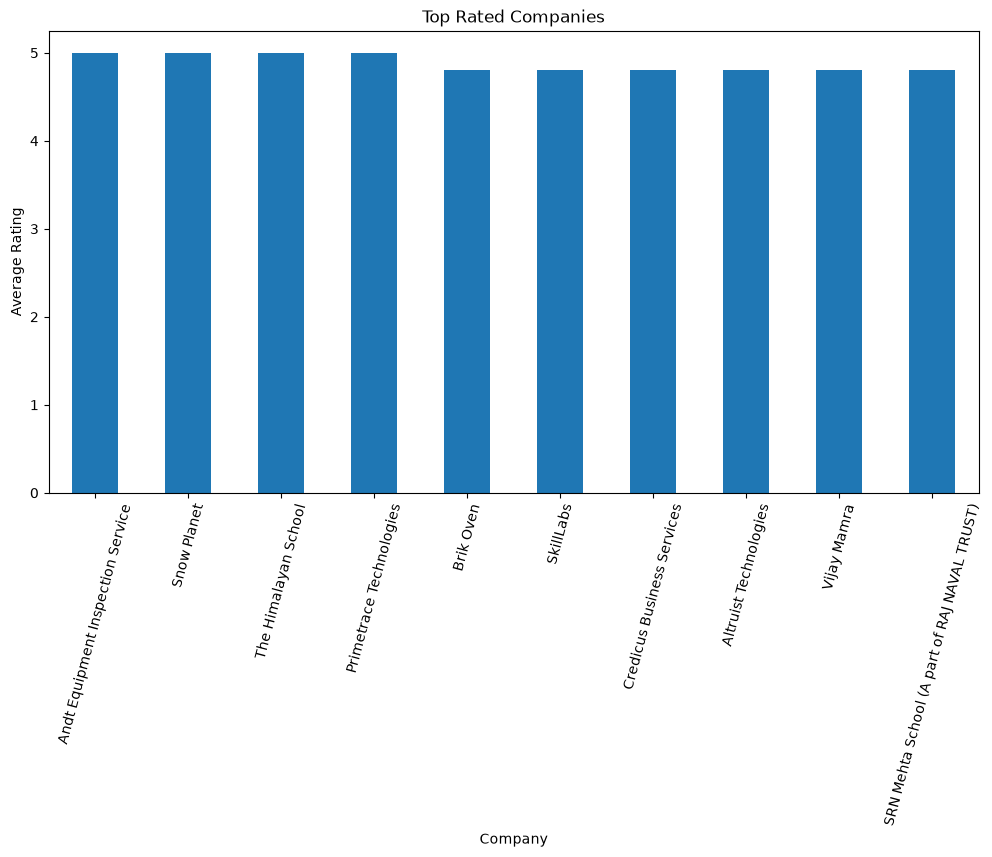

In [45]:
plt.figure(figsize=(12,6))

top_rated['AverageRating'].plot(kind='bar')

plt.title("Top Rated Companies")
plt.xlabel("Company")
plt.ylabel("Average Rating")

plt.xticks(rotation=75)

plt.show()

In [46]:
# Convert skills into a list

skills = (
    df['tagsAndSkills']
    .dropna()
    .str.split(',')
)

skills.head()

0    [Communication, Manpower, Staffing, Convincing...
1    [Safety Officer Activities, Fire Protection, F...
2    [Performance Marketing, User Acquisition, grow...
3    [Fluent English, Spoken English, Good English ...
4    [Product Marketing, CNS, Product Management, N...
Name: tagsAndSkills, dtype: object

In [47]:
from collections import Counter

skill_counter = Counter()

for skill_list in skills:
    if isinstance(skill_list, list):
        cleaned = [skill.strip() for skill in skill_list]
        skill_counter.update(cleaned)

top_skills = pd.DataFrame(
    skill_counter.most_common(20),
    columns=['Skill', 'Count']
)

top_skills

,Skill,Count
0,Sales,6480
1,Management,4856
2,project management,3972
3,python,3962
4,css,3789
5,Development,3283
6,sap,3202
7,sales,2726
8,Communication Skills,2523
9,c#,2423


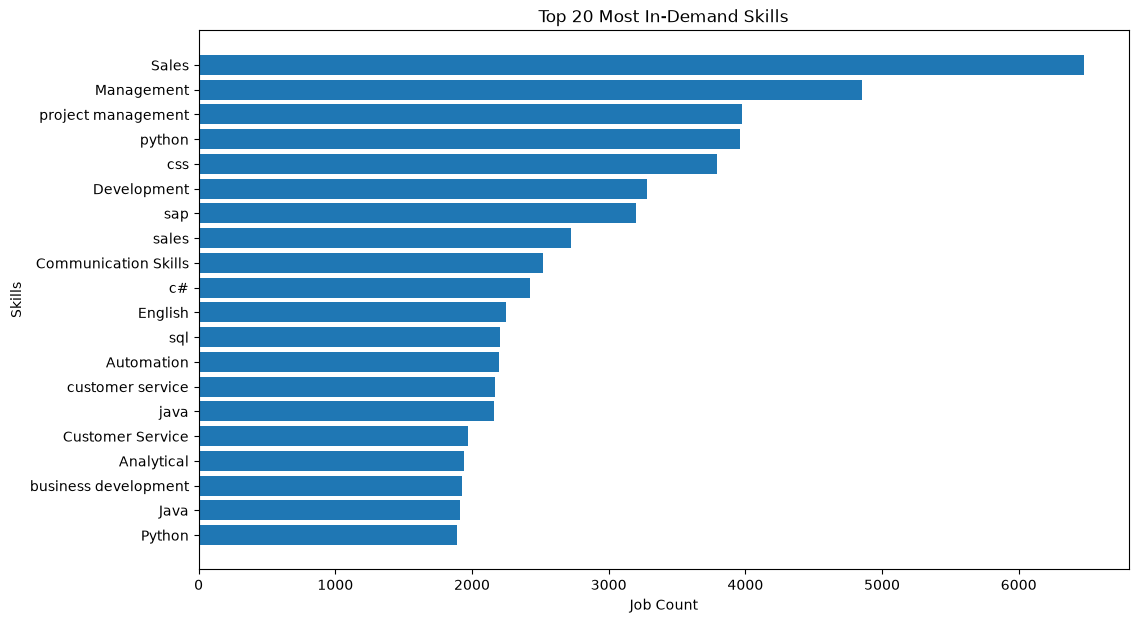

In [48]:
plt.figure(figsize=(12,7))

plt.barh(top_skills['Skill'], top_skills['Count'])

plt.title("Top 20 Most In-Demand Skills")
plt.xlabel("Job Count")
plt.ylabel("Skills")

plt.gca().invert_yaxis()

plt.show()

In [49]:
# Export cleaned dataset

df.to_csv("../Dataset/Indian_Job_Market_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [50]:
# Save Top Skills

top_skills.to_csv("../Dataset/Top_20_Skills.csv", index=False)

print("Top skills exported successfully!")

Top skills exported successfully!


In [51]:
print("=" * 50)
print("Indian Job Market Analysis Completed Successfully!")
print("=" * 50)

print(f"Total Jobs: {len(df)}")
print(f"Total Companies: {df['companyName'].nunique()}")
print(f"Total Locations: {df['location'].nunique()}")
print(f"Total Job Titles: {df['title'].nunique()}")

print("=" * 50)

Indian Job Market Analysis Completed Successfully!
Total Jobs: 97929
Total Companies: 18668
Total Locations: 10066
Total Job Titles: 55104
